In [31]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
train_df = pd.read_csv("train_data.csv")
composers = pd.read_csv("composers.csv")
train_df["id"].nunique()

400

# Data

In [33]:
def create_musical_vocab(df):
    df = df.copy()

    df["interval"] = df.groupby("id")["pitch"].diff().fillna(0).astype(int)

    df["quant_dur"] = (df["duration"] * 4).round() / 4

    df["token"] = "i" + df["interval"].astype(str) + "d" + df["quant_dur"].astype(str)

    return df.groupby("id")["token"].apply(lambda x: " ".join(x))


def get_meta_features(df):
    return df.groupby("id").agg(
        {
            "pitch": ["mean", "std", "min", "max"],
            "duration": ["mean", "std", "sum", "count"],
        }
    )

In [34]:
train_vocab = create_musical_vocab(train_df)
train_vocab

id
0      i0d0.0 i-20d0.5 i6d0.75 i-36d0.25 i26d1.0 i-28...
1      i0d0.5 i18d0.75 i16d0.25 i-40d1.0 i44d0.75 i11...
2      i0d0.75 i14d0.75 i-8d0.75 i27d0.75 i25d0.5 i-1...
4      i0d0.75 i23d0.75 i-20d0.25 i7d1.0 i32d0.75 i-4...
5      i0d0.25 i16d0.25 i5d0.25 i21d0.75 i-9d0.75 i9d...
                             ...                        
495    i0d0.5 i3d0.25 i17d1.0 i-2d0.5 i-27d0.25 i5d0....
496    i0d0.5 i0d0.25 i-2d0.5 i1d0.25 i41d0.25 i-25d0...
497    i0d0.25 i3d0.25 i-12d0.75 i5d0.25 i-27d0.25 i4...
498    i0d0.5 i-44d1.0 i45d0.75 i-23d0.5 i7d1.0 i10d0...
499    i0d0.25 i-27d1.0 i9d0.75 i46d0.75 i-23d0.75 i-...
Name: token, Length: 400, dtype: str

In [35]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=3000, sublinear_tf=True)
X_tfidf_train = vectorizer.fit_transform(train_vocab).toarray()

In [36]:
X_tfidf_train.shape

(400, 3000)

In [37]:
X_meta_train = get_meta_features(train_df).loc[train_vocab.index].values
X_train_full = np.hstack([X_tfidf_train, X_meta_train])
X_train_full.shape

(400, 3008)

In [38]:
le = LabelEncoder()
y_all = le.fit_transform(composers.set_index("datapointID").loc[train_vocab.index]["answer"])

In [39]:
np.unique(y_all, return_counts=True)

(array([0, 1, 2, 3, 4]), array([80, 80, 80, 80, 80]))

# Data 2

<Axes: xlabel='duration', ylabel='Count'>

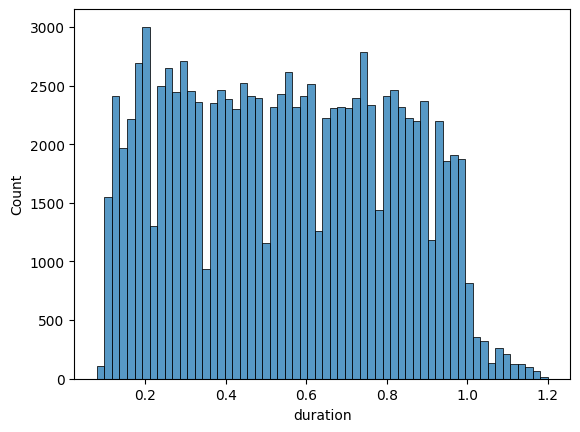

In [ ]:
sns.histplot(train_df['duration'])


# Model

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_all, test_size=0.1, stratify=y_all, random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=400,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
    class_weight="balanced",
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

<Axes: ylabel='Count'>

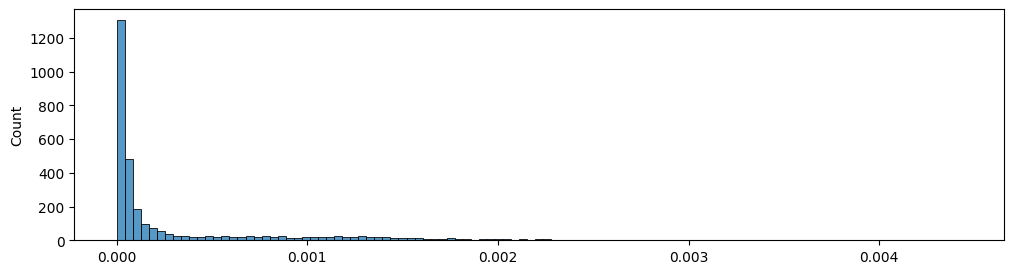

In [ ]:
plt.figure(figsize=(12, 3))
sns.histplot(np.sort(model.feature_importances_))

In [ ]:
val_preds = model.predict(X_val)
print(f"Validation F1: {f1_score(y_val, val_preds, average='weighted'):.4f}")

Validation F1: 0.6156


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_val, val_preds)

0.625